# Restaurant Branch Performance — Exploratory Data Analysis (EDA)

**Objective:** Explore the Restaurant Branch Performance dataset using **Pandas** to understand summary statistics, distributions, relationships among numerical variables, and performance differences across branches, regions, and store types.

### Key questions
- How are customers, revenue, profit, marketing spend, staffing, delivery time, and ratings distributed?
- Which branches, regions, and store types perform best?
- Which numerical variables have the strongest relationships?
- What practical, data-driven observations can be drawn from the dataset?


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load dataset
from pathlib import Path

candidate_paths = [
    Path("Day13_Restaurant_Branch_Performance_Dataset.csv"),
    Path("/content/Day13_Restaurant_Branch_Performance_Dataset.csv"),
    Path("/mnt/data/Day13_Restaurant_Branch_Performance_Dataset.csv"),
]
file_path = next((p for p in candidate_paths if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Dataset not found. Upload 'Day13_Restaurant_Branch_Performance_Dataset.csv' "
        "to the notebook/Colab session and rerun this cell."
    )

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal


## 1. Dataset Structure and Data Quality

In [28]:
# Basic structure
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values by categorical column:")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 1

,Missing_Count
Promotion,184
Record_ID,0
Day,0
Month,0
Branch,0
Date,0
Region,0
Store_Type,0
Marketing_Spend,0
Staff_Count,0



Duplicate rows: 0

Unique values by categorical column:
Record_ID: 350 unique
Date: 161 unique
Day: 7 unique
Month: 6 unique
Branch: 8 unique
Region: 3 unique
Store_Type: 3 unique
Weather: 4 unique
Promotion: 3 unique


In [29]:
# Convert Date to datetime and inspect the time range
df["Date"] = pd.to_datetime(df["Date"])
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

# Promotion has missing values; keep them as a meaningful category for grouped EDA
df["Promotion"] = df["Promotion"].fillna("No Promotion")

df.describe(include="all").T


Date range: 2026-01-01 to 2026-06-30


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Record_ID,350,350,ST0350,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,350,NaN,NaN,NaN,2026-03-30 00:37:01.714285824,2026-01-01 00:00:00,2026-02-15 00:00:00,2026-03-26 00:00:00,2026-05-16 18:00:00,2026-06-30 00:00:00,NaN
Day,350,7,Tuesday,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,350,6,February,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,350,8,Srinagar,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,350,3,South,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,350,3,Standard,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Staff_Count,350.00,NaN,NaN,NaN,11.96,5.00,9.00,11.00,15.00,24.00,4.34
Marketing_Spend,350.00,NaN,NaN,NaN,"5,516.35",725.35,"4,339.73","5,393.37","6,748.50","11,784.96","2,050.91"
Customers,350.00,NaN,NaN,NaN,217.38,77.00,180.25,213.00,255.75,360.00,56.72


### Initial data-quality observations
- The dataset contains **350 records and 22 columns**.
- The numerical business-performance fields are complete.
- `Promotion` contains missing values; these are treated as **No Promotion** for comparison rather than dropping observations.
- `Date` is converted to datetime for time-aware analysis.


## 2. Summary Statistics and Descriptive Analysis

In [30]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

summary = df[numeric_cols].describe().T
summary["IQR"] = summary["75%"] - summary["25%"]
summary["CV_%"] = (summary["std"] / summary["mean"]) * 100

display(summary.round(2))


,count,mean,std,min,25%,50%,75%,max,IQR,CV_%
Staff_Count,350.00,11.96,4.34,5.00,9.00,11.00,15.00,24.00,6.00,36.28
Marketing_Spend,350.00,"5,516.35","2,050.91",725.35,"4,339.73","5,393.37","6,748.50","11,784.96","2,408.77",37.18
Customers,350.00,217.38,56.72,77.00,180.25,213.00,255.75,360.00,75.50,26.09
Orders,350.00,187.05,50.56,71.00,155.00,182.50,218.75,334.00,63.75,27.03
Average_Bill,350.00,388.91,82.49,180.00,337.32,383.48,441.76,623.28,104.45,21.21
Revenue,350.00,"86,831.80","36,644.45","20,540.76","61,261.72","79,766.88","102,976.18","194,018.92","41,714.47",42.20
Food_Cost,350.00,"31,807.55","13,896.89","7,262.01","22,326.66","28,861.32","38,370.37","75,946.59","16,043.71",43.69
Operating_Cost,350.00,"56,621.44","18,467.84","20,782.38","43,797.67","53,723.02","63,961.23","111,489.14","20,163.56",32.62
Profit,350.00,"30,210.36","19,508.59","-6,924.68","16,915.49","26,873.87","39,823.74","89,096.19","22,908.25",64.58
Avg_Delivery_Min,350.00,26.10,4.39,13.90,22.80,26.10,29.08,38.30,6.28,16.81


In [31]:
# Business KPIs
kpis = df[[
    "Staff_Count", "Marketing_Spend", "Customers", "Orders",
    "Average_Bill", "Revenue", "Food_Cost", "Operating_Cost",
    "Profit", "Avg_Delivery_Min", "Customer_Rating"
]].agg(["mean", "median", "min", "max"]).T

display(kpis.round(2))


,mean,median,min,max
Staff_Count,11.96,11.00,5.00,24.00
Marketing_Spend,"5,516.35","5,393.37",725.35,"11,784.96"
Customers,217.38,213.00,77.00,360.00
Orders,187.05,182.50,71.00,334.00
Average_Bill,388.91,383.48,180.00,623.28
Revenue,"86,831.80","79,766.88","20,540.76","194,018.92"
Food_Cost,"31,807.55","28,861.32","7,262.01","75,946.59"
Operating_Cost,"56,621.44","53,723.02","20,782.38","111,489.14"
Profit,"30,210.36","26,873.87","-6,924.68","89,096.19"
Avg_Delivery_Min,26.10,26.10,13.90,38.30


## 3. Distribution Analysis

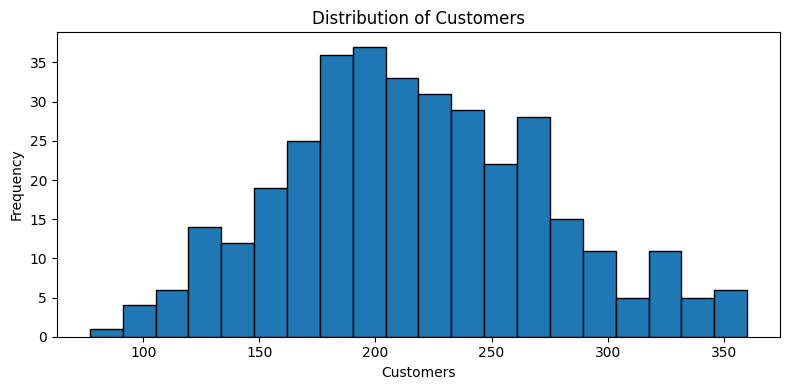

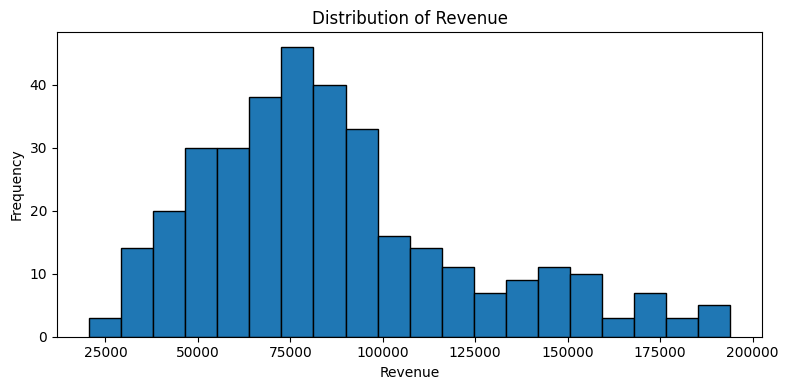

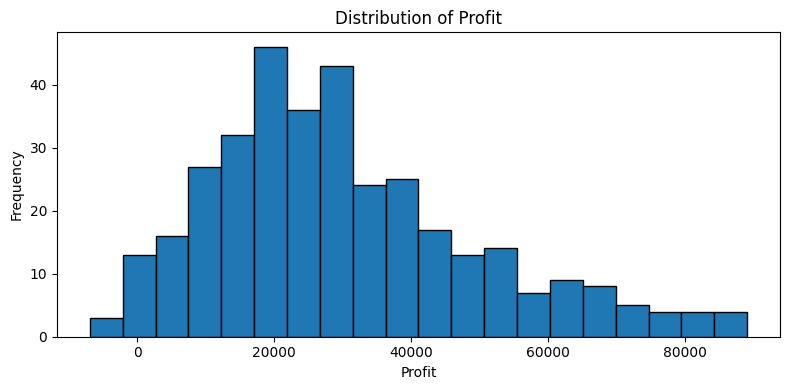

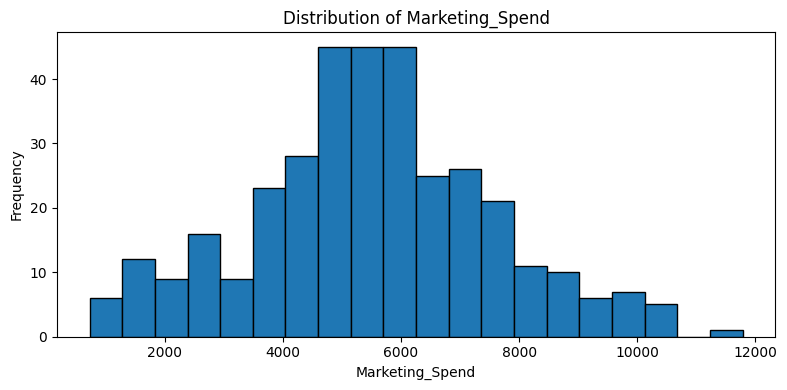

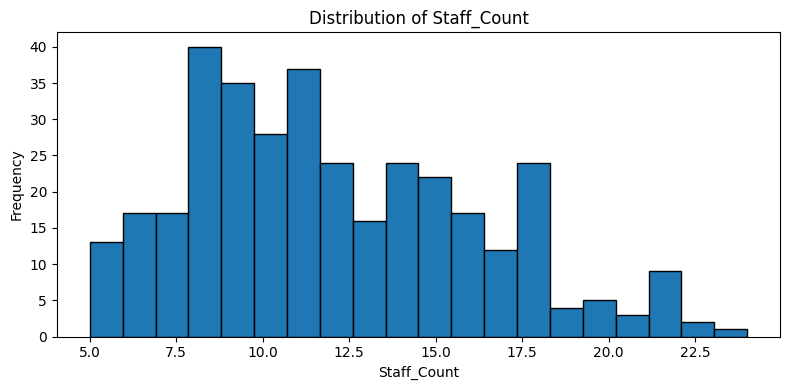

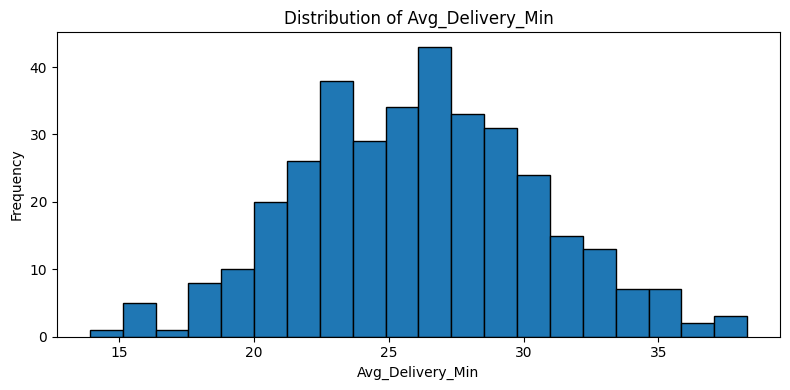

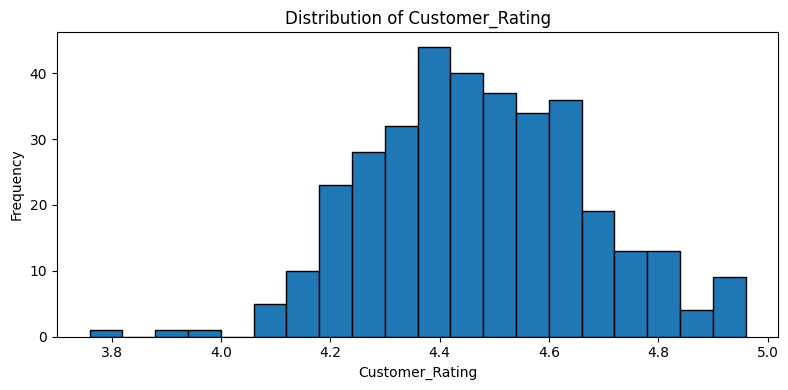

In [32]:
# Histograms for important numerical business variables
important_num = [
    "Customers", "Revenue", "Profit", "Marketing_Spend",
    "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"
]

for col in important_num:
    plt.figure(figsize=(8, 4))
    df[col].plot(kind="hist", bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


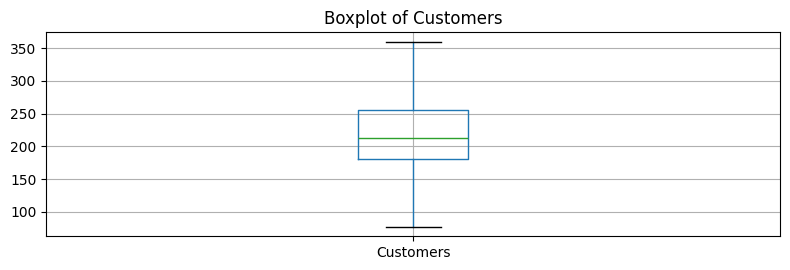

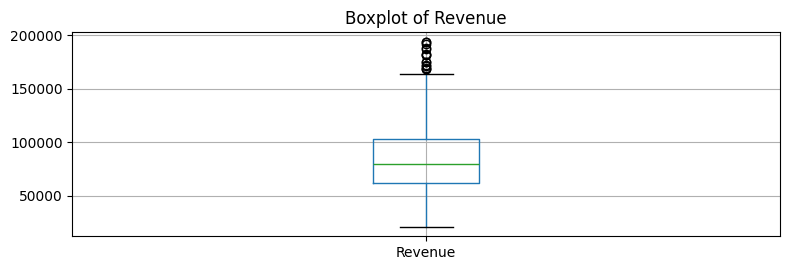

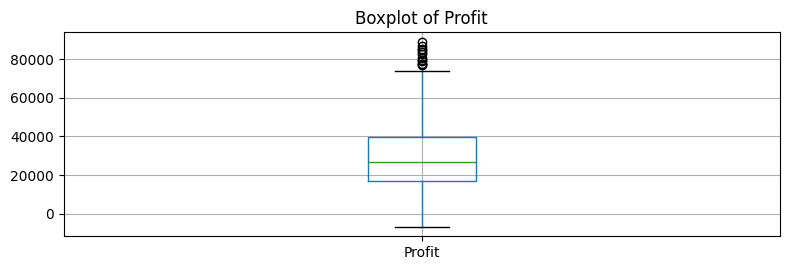

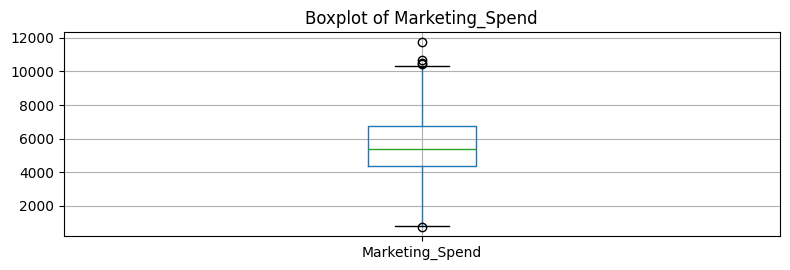

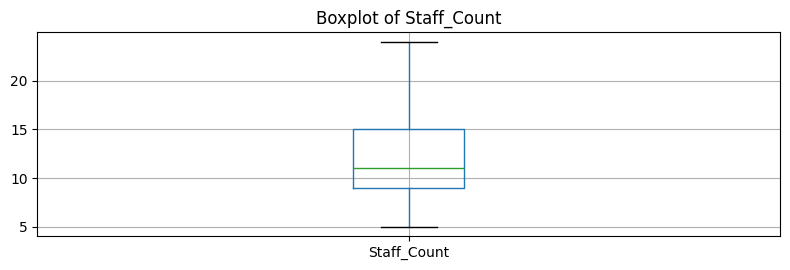

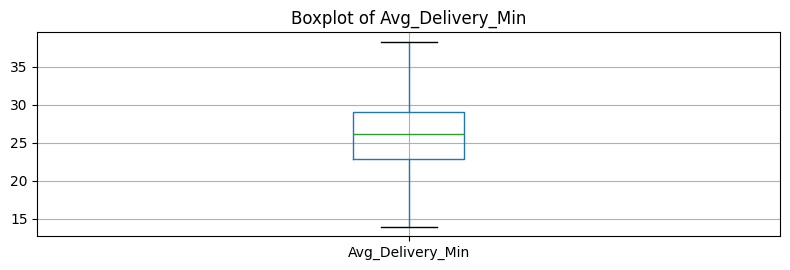

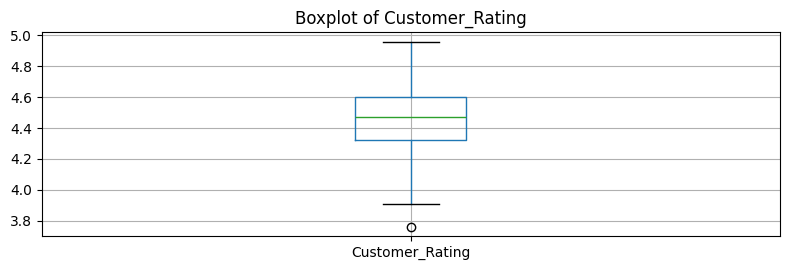

In [33]:
# Boxplots to inspect spread and potential outliers
for col in important_num:
    plt.figure(figsize=(8, 2.8))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


## 4. Performance Across Branches

We compare average customers, revenue, profit, marketing spend, staffing, delivery time, and ratings by branch. Because branches have different numbers of observations, the analysis uses both **mean performance** and observation counts.


In [34]:
branch_summary = (
    df.groupby("Branch")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Marketing_Spend=("Marketing_Spend", "mean"),
          Avg_Staff=("Staff_Count", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(branch_summary.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Branch,,,,,,,,
Bengaluru,46,227.50,"90,732.12","31,890.91","5,413.93",12.85,26.56,4.47
Hyderabad,43,220.79,"88,804.90","31,402.98","5,455.15",12.28,25.52,4.47
Delhi,32,213.97,"87,573.87","31,385.30","5,762.63",11.56,25.69,4.49
Pune,37,214.92,"88,107.49","31,265.57","5,590.57",11.86,25.53,4.54
Jaipur,48,223.27,"86,746.16","30,469.70","5,356.64",11.71,26.58,4.47
Srinagar,52,214.73,"86,746.47","30,302.92","5,413.67",12.46,25.97,4.48
Kochi,48,209.06,"85,574.62","28,902.04","5,660.43",11.83,25.84,4.42
Mumbai,44,213.77,"80,779.25","26,580.99","5,580.10",10.89,26.86,4.44


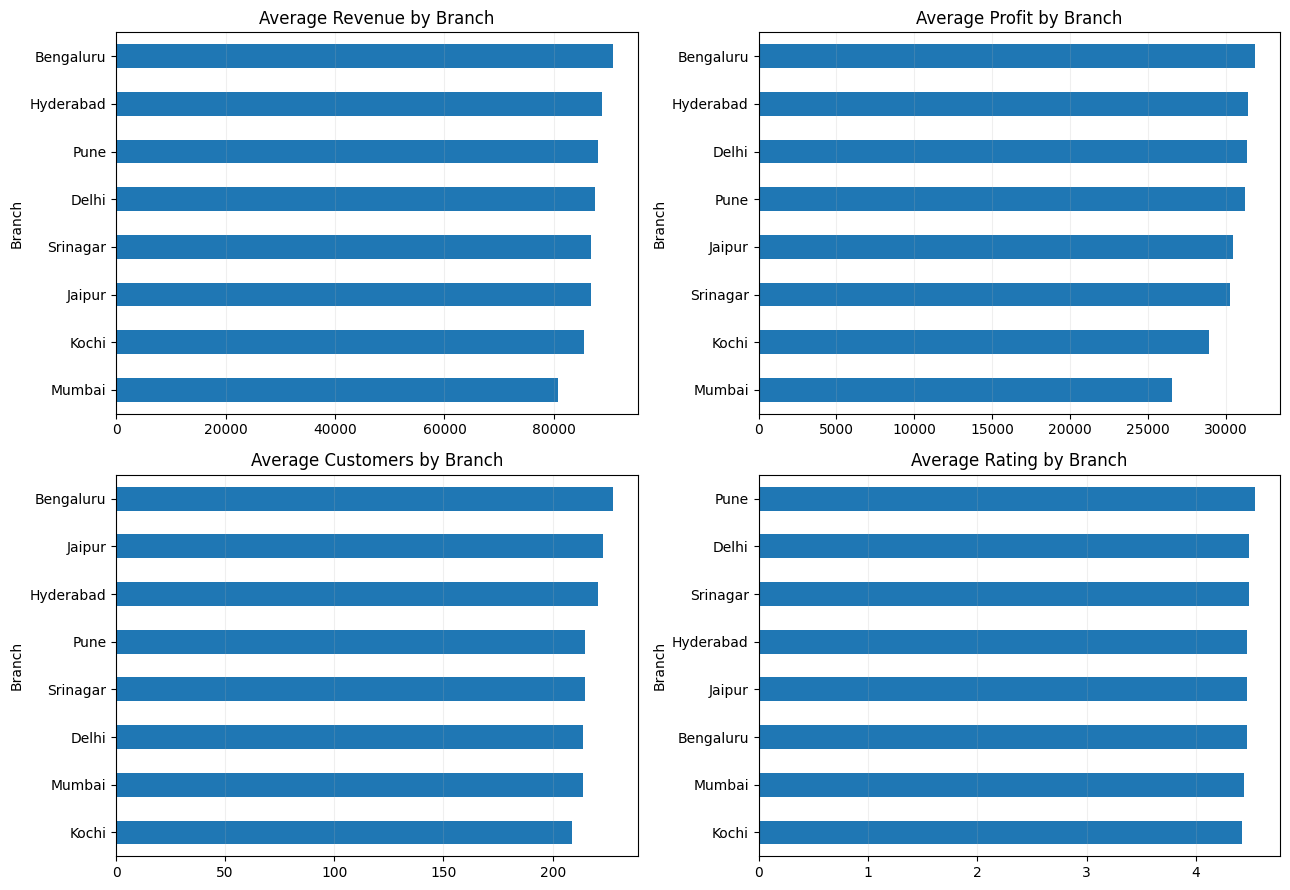

In [35]:
# Branch comparison charts
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

branch_summary["Avg_Revenue"].sort_values().plot(kind="barh", ax=axes[0,0], title="Average Revenue by Branch")
branch_summary["Avg_Profit"].sort_values().plot(kind="barh", ax=axes[0,1], title="Average Profit by Branch")
branch_summary["Avg_Customers"].sort_values().plot(kind="barh", ax=axes[1,0], title="Average Customers by Branch")
branch_summary["Avg_Rating"].sort_values().plot(kind="barh", ax=axes[1,1], title="Average Rating by Branch")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 5. Performance by Region and Store Type

In [36]:
def group_performance(group_col):
    return (
        df.groupby(group_col)
          .agg(
              Records=("Record_ID", "count"),
              Avg_Customers=("Customers", "mean"),
              Avg_Revenue=("Revenue", "mean"),
              Avg_Profit=("Profit", "mean"),
              Avg_Marketing_Spend=("Marketing_Spend", "mean"),
              Avg_Staff=("Staff_Count", "mean"),
              Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
              Avg_Rating=("Customer_Rating", "mean")
          )
          .sort_values("Avg_Profit", ascending=False)
    )

region_summary = group_performance("Region")
store_summary = group_performance("Store_Type")

print("REGION PERFORMANCE")
display(region_summary.round(2))

print("STORE TYPE PERFORMANCE")
display(store_summary.round(2))


REGION PERFORMANCE


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Region,,,,,,,,
South,137,218.93,"88,320.22","30,690.57","5,513.23",12.31,25.98,4.45
North,132,217.65,"86,946.94","30,625.96","5,477.53",11.97,26.13,4.48
West,81,214.30,"84,126.72","28,720.86","5,584.88",11.33,26.25,4.49


STORE TYPE PERFORMANCE


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Store_Type,,,,,,,,
Premium,52,298.73,"152,867.31","62,890.24","8,065.56",17.60,26.40,4.46
Standard,196,224.98,"87,268.67","30,630.79","5,044.90",12.54,25.98,4.47
Express,102,161.29,"52,327.16","12,742.14","5,122.66",7.96,26.17,4.46


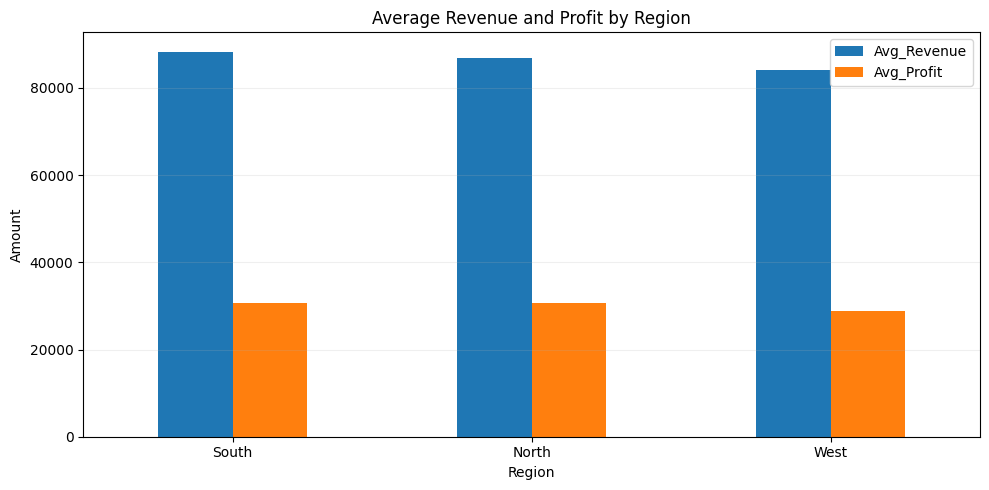

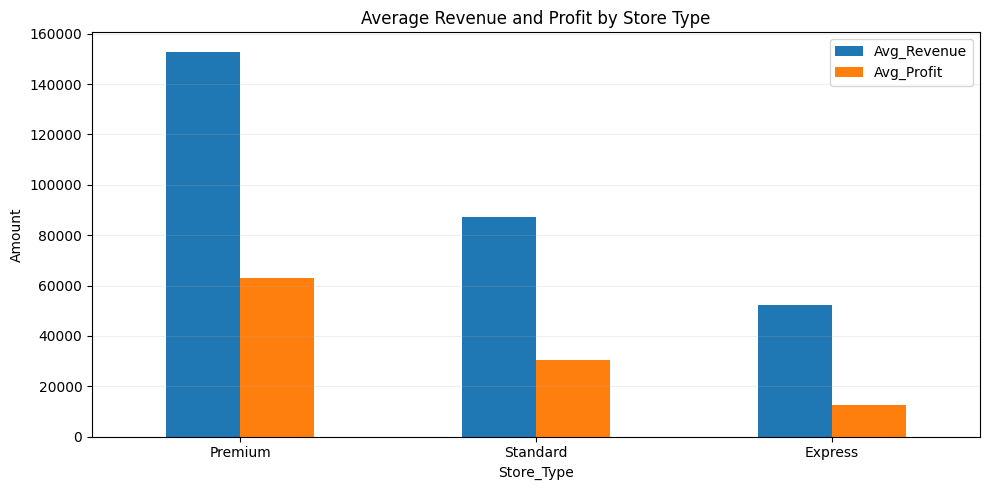

In [37]:
# Region and store-type visual comparison
for group_col, title in [("Region", "Region"), ("Store_Type", "Store Type")]:
    grouped = group_performance(group_col)
    grouped[["Avg_Revenue", "Avg_Profit"]].plot(kind="bar", figsize=(10, 5))
    plt.title(f"Average Revenue and Profit by {title}")
    plt.ylabel("Amount")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


## 6. Marketing, Promotion, Weather, and Customer Experience

In [38]:
promotion_summary = (
    df.groupby("Promotion")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Revenue", ascending=False)
)

weather_summary = (
    df.groupby("Weather")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Revenue", ascending=False)
)

print("PROMOTION PERFORMANCE")
display(promotion_summary.round(2))

print("WEATHER PERFORMANCE")
display(weather_summary.round(2))


PROMOTION PERFORMANCE


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Delivery_Min,Avg_Rating
Promotion,,,,,,
Loyalty Offer,33,226.97,"91,937.89","32,346.09",26.35,4.44
Weekend Offer,74,224.54,"88,808.72","31,730.63",26.96,4.45
Combo Deal,59,218.64,"86,269.73","29,779.94",25.73,4.45
No Promotion,184,212.37,"85,301.20","29,353.92",25.82,4.49


WEATHER PERFORMANCE


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Delivery_Min,Avg_Rating
Weather,,,,,,
Rain,48,226.85,"92,974.88","33,632.76",25.95,4.46
Hot,31,213.03,"87,830.13","31,759.74",27.23,4.44
Cloudy,82,216.10,"87,724.00","31,059.27",26.24,4.49
Clear,189,216.24,"84,720.81","28,718.73",25.89,4.47


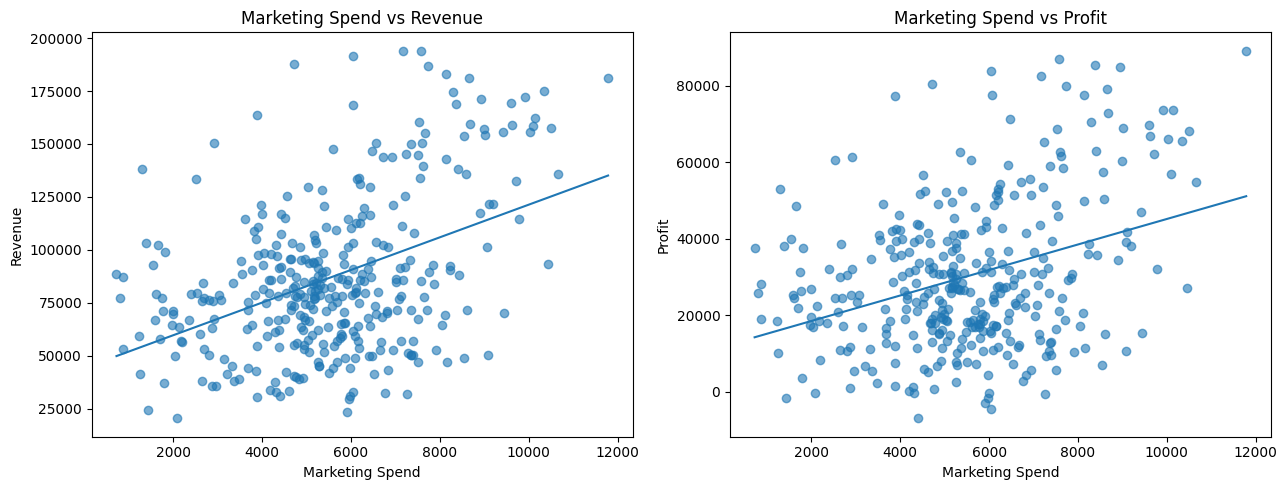

In [39]:
# Marketing spend vs revenue/profit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Marketing_Spend"], df["Revenue"], alpha=0.6)
z = np.polyfit(df["Marketing_Spend"], df["Revenue"], 1)
xline = np.linspace(df["Marketing_Spend"].min(), df["Marketing_Spend"].max(), 100)
axes[0].plot(xline, np.poly1d(z)(xline))
axes[0].set_title("Marketing Spend vs Revenue")
axes[0].set_xlabel("Marketing Spend")
axes[0].set_ylabel("Revenue")

axes[1].scatter(df["Marketing_Spend"], df["Profit"], alpha=0.6)
z = np.polyfit(df["Marketing_Spend"], df["Profit"], 1)
axes[1].plot(xline, np.poly1d(z)(xline))
axes[1].set_title("Marketing Spend vs Profit")
axes[1].set_xlabel("Marketing Spend")
axes[1].set_ylabel("Profit")

plt.tight_layout()
plt.show()


## 7. Correlation Analysis

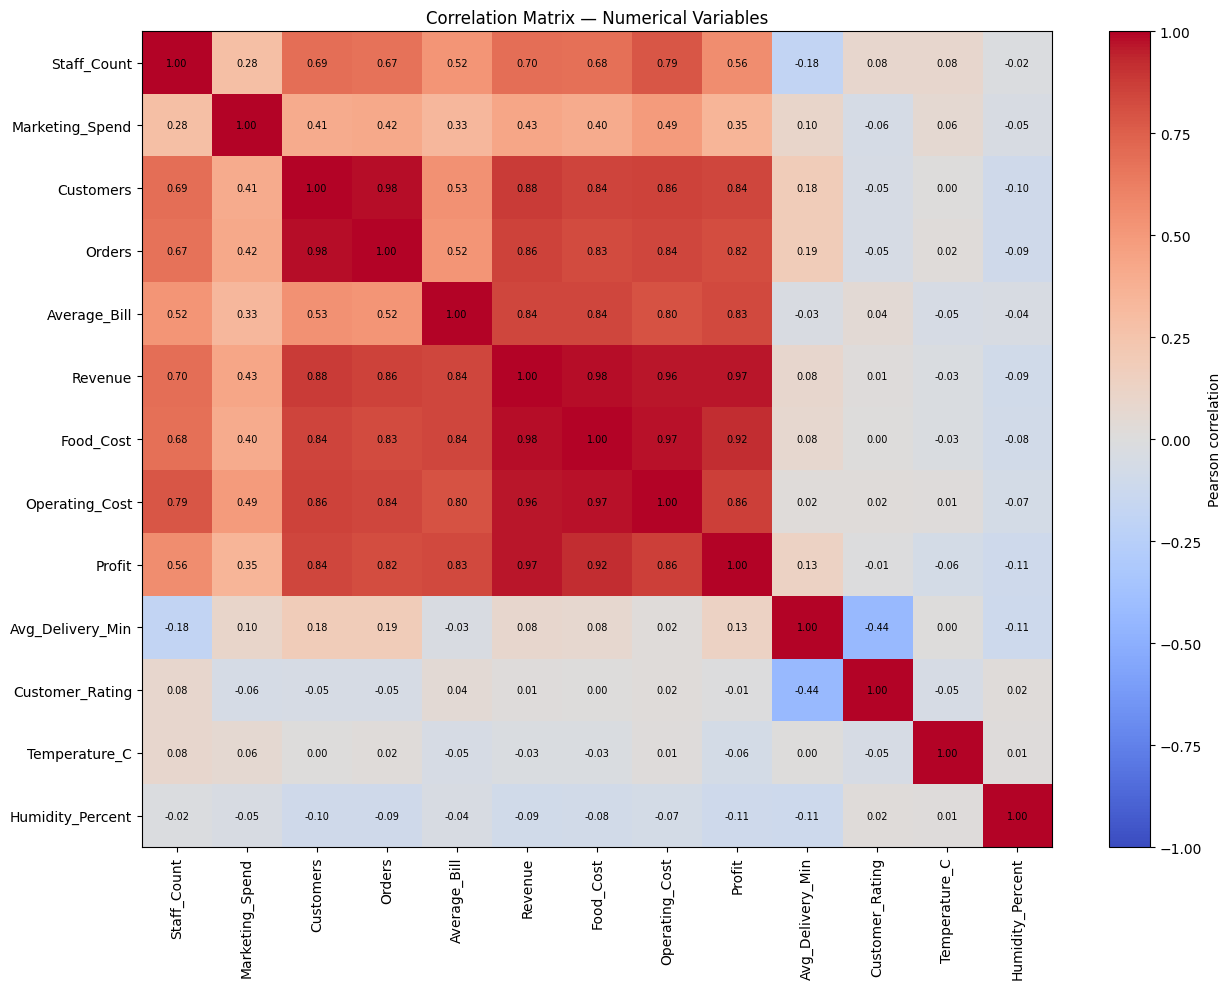

In [40]:
# Pearson correlation matrix for numerical variables
corr = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(13, 10))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for r in range(len(corr.index)):
    for col_idx in range(len(corr.columns)):
        plt.text(col_idx, r, f"{corr.iloc[r, col_idx]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()


In [41]:
# Rank the strongest absolute correlations (excluding self-correlations)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_corr = (
    upper.stack()
         .sort_values(key=lambda s: s.abs(), ascending=False)
         .to_frame("Pearson_r")
)

display(strong_corr.head(15).round(3))


Pearson_r
Customers      Orders               0.98
Revenue        Food_Cost            0.98
Food_Cost      Operating_Cost       0.97
Revenue        Profit               0.97
               Operating_Cost       0.96
Food_Cost      Profit               0.92
Customers      Revenue              0.88
Operating_Cost Profit               0.86
Orders         Revenue              0.86
Customers      Operating_Cost       0.86
               Food_Cost            0.84
Average_Bill   Revenue              0.84
Orders         Operating_Cost       0.84
Average_Bill   Food_Cost            0.84
Customers      Profit               0.84

### Correlation interpretation
Correlation measures linear association, not causation. Very high correlations among `Customers`, `Orders`, `Revenue`, `Food_Cost`, and `Operating_Cost` are expected because these measures are operationally connected. The matrix is therefore most useful for identifying relationships that may be less mechanically linked, such as marketing spend, staffing, delivery time, and customer ratings.


## 8. Additional Relationship Analysis

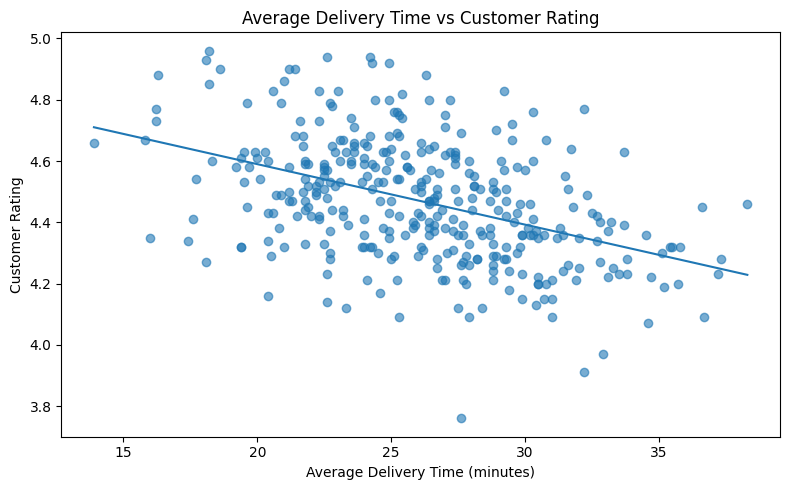

In [42]:
# Delivery time vs rating
plt.figure(figsize=(8, 5))
plt.scatter(df["Avg_Delivery_Min"], df["Customer_Rating"], alpha=0.6)

z = np.polyfit(df["Avg_Delivery_Min"], df["Customer_Rating"], 1)
xline = np.linspace(df["Avg_Delivery_Min"].min(), df["Avg_Delivery_Min"].max(), 100)
plt.plot(xline, np.poly1d(z)(xline))

plt.title("Average Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()


## 9. Data-Driven Observations

In [43]:
# Automatically calculate a few headline comparisons used in the conclusions
best_branch_profit = branch_summary["Avg_Profit"].idxmax()
best_branch_revenue = branch_summary["Avg_Revenue"].idxmax()
best_branch_customers = branch_summary["Avg_Customers"].idxmax()

best_region_profit = region_summary["Avg_Profit"].idxmax()
best_store_profit = store_summary["Avg_Profit"].idxmax()
best_store_revenue = store_summary["Avg_Revenue"].idxmax()

marketing_revenue_corr = df["Marketing_Spend"].corr(df["Revenue"])
marketing_profit_corr = df["Marketing_Spend"].corr(df["Profit"])
delivery_rating_corr = df["Avg_Delivery_Min"].corr(df["Customer_Rating"])

print(f"1. {best_branch_profit} has the highest average profit among branches.")
print(f"2. {best_branch_revenue} has the highest average revenue among branches.")
print(f"3. {best_branch_customers} has the highest average customer count among branches.")
print(f"4. {best_region_profit} is the strongest region by average profit.")
print(f"5. {best_store_profit} is the strongest store type by average profit, while {best_store_revenue} has the highest average revenue.")
print(f"6. Marketing spend has a Pearson correlation of {marketing_revenue_corr:.2f} with revenue and {marketing_profit_corr:.2f} with profit.")
print(f"7. Delivery time and customer rating have a Pearson correlation of {delivery_rating_corr:.2f}.")
print(f"8. Customers and orders have a Pearson correlation of {corr.loc['Customers','Orders']:.2f}, showing a very strong operational relationship.")


1. Bengaluru has the highest average profit among branches.
2. Bengaluru has the highest average revenue among branches.
3. Bengaluru has the highest average customer count among branches.
4. South is the strongest region by average profit.
5. Premium is the strongest store type by average profit, while Premium has the highest average revenue.
6. Marketing spend has a Pearson correlation of 0.43 with revenue and 0.35 with profit.
7. Delivery time and customer rating have a Pearson correlation of -0.44.
8. Customers and orders have a Pearson correlation of 0.98, showing a very strong operational relationship.


## 10. Conclusion

The EDA shows that restaurant performance is primarily associated with customer/order volume and the resulting revenue and cost structure. Branch-level and store-type comparisons reveal meaningful differences in average performance, while the correlation matrix highlights both direct operational relationships and weaker relationships involving marketing, delivery, staffing, and ratings.

The strongest conclusions should be interpreted as **associations in this dataset**, not causal effects. For example, a positive marketing–revenue relationship does not by itself prove that increasing marketing spend will cause the same increase in revenue. Business decisions should combine these findings with controlled experiments, longer time-series data, and branch-specific context.
